In this notebook, filters are applied to the UAV indoor dataset to investigate the qvio trajectory and how filter implementation affect on the present estimation.

In [14]:
import os
import sys
sys.path.append('/app/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
from datetime import datetime
import seaborn as sns
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
from utils.error_report import get_error_from_list, get_error_report
from utils import lla_to_enu, lla_to_ned

from data_loader import UAV_DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, ErrorEnum
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters import (
    ExtendedKalmanFilter,
    UnscentedKalmanFilter,
    ParticleFilter, ResamplingAlgorithms,
    EnsembleKalmanFilter,
    CubatureKalmanFilter
)
from numpy.linalg import norm
from decimal import Decimal, getcontext

%matplotlib inline
np.random.seed(777)

## Load UAV indoor data

In [15]:
root_path = "../../../data"

loader = UAV_DataLoader(
    root_path=root_path, 
    sequence_nr="log0003",
    imu_config_filepath="/app/src/data_Loader/imu_config.yaml"
)
voxl_vo_vel_columns = ['vel_imu_wrt_vio_x(m/s)', 'vel_imu_wrt_vio_y(m/s)', 'vel_imu_wrt_vio_z(m/s)']

VO estimate data not found.
UWB position data not found.


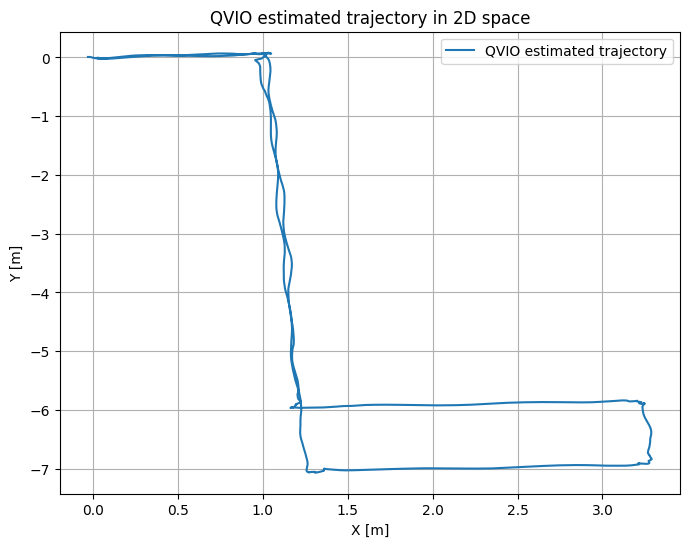

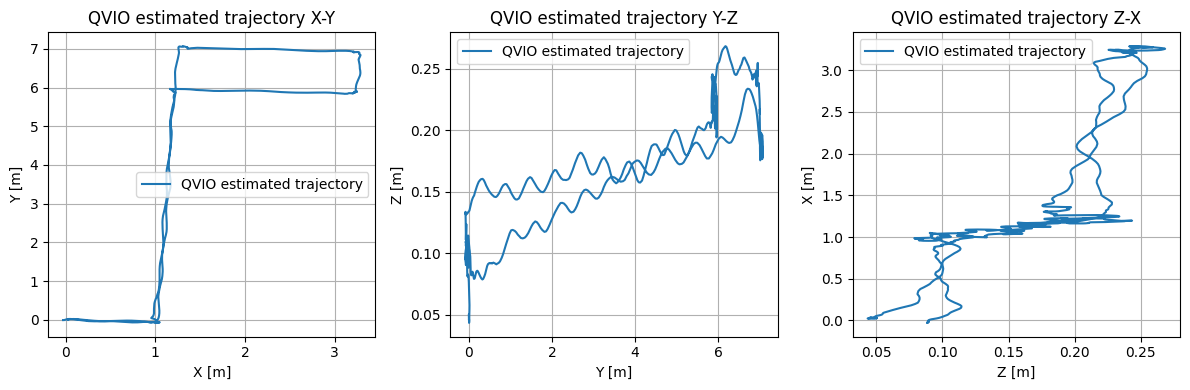

In [16]:
loader.visualize_qvio_trajectory(dimension=2, detail=True)

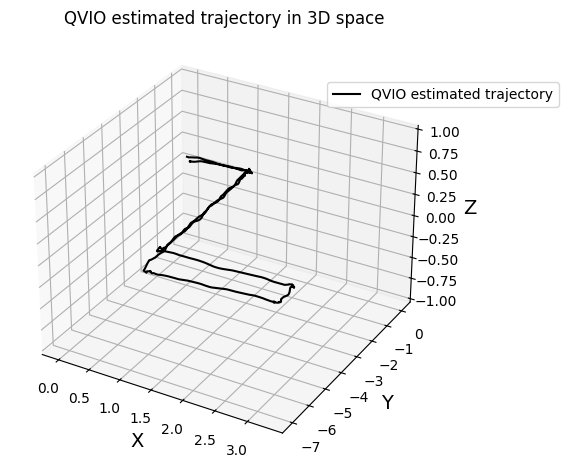

In [17]:
loader.visualize_qvio_trajectory(dimension=3, z_lim=(-1.0, 1.0))

In [18]:
def visualize_trajectory(loader, mu_x, mu_y, mu_z, label="EKF estimated trajectory vs Vehicle odometry trajectory"):
    fig = plt.figure()
    
    ax1 = fig.add_subplot(111, projection='3d')
    ax1.set_title(label)
    
    xs, ys, zs = loader.voxl_qvio_df[['T_imu_wrt_vio_x(m)', 'T_imu_wrt_vio_y(m)', 'T_imu_wrt_vio_z(m)']].values.T
    ax1.plot(xs, ys, zs, label='QVIO estimated trajectory', color='black')
    ax1.plot(mu_x, mu_y, mu_z, label='Estimated trajectory', color='red')
    
    ax1.set_xlabel('$X$', fontsize=14)
    ax1.set_ylabel('$Y$', fontsize=14)
    ax1.set_zlabel('$Z$', fontsize=14)
    
    ax1.legend(loc='best', bbox_to_anchor=(1.1, 0., 0.2, 0.9))
    fig.tight_layout()
    plt.show()
    
    fig2, axs = plt.subplots(1, 3, figsize=(12, 4))

    vo_color='black'
    color='blue'
    
    x, y = loader.voxl_qvio_df[['T_imu_wrt_vio_x(m)', 'T_imu_wrt_vio_y(m)']].values.T
    axs[0].plot(x, y, label='QVIO estimated trajectory', color=vo_color)
    axs[0].plot(mu_x, mu_y, label='Estimated trajectory', color=color)
    axs[0].set_title("Estimated trajectory X-Y")
    axs[0].set_xlabel('X [m]')
    axs[0].set_ylabel('Y [m]')
    axs[0].legend()
    axs[0].grid()
    
    x, z = loader.voxl_qvio_df[['T_imu_wrt_vio_y(m)', 'T_imu_wrt_vio_z(m)']].values.T
    axs[1].plot(x, z, label='QVIO estimated trajectory', color=vo_color)
    axs[1].plot(mu_x, mu_z, label='Estimated trajectory', color=color)
    axs[1].set_title("QVIO estimated trajectory Y-Z")
    axs[1].set_xlabel('Y [m]')
    axs[1].set_ylabel('Z [m]')
    axs[1].legend()
    axs[1].grid()
    
    z, x = loader.voxl_qvio_df[['T_imu_wrt_vio_z(m)', 'T_imu_wrt_vio_x(m)']].values.T
    axs[2].plot(z, x, label='QVIO estimated trajectory', color=vo_color)
    axs[2].plot(mu_z, mu_x, label='Estimated trajectory', color=color)
    axs[2].set_title("QVIO estimated trajectory Z-X")
    
    axs[2].set_xlabel('Z [m]')
    axs[2].set_ylabel('X [m]')
    axs[2].legend()
    axs[2].grid()

    fig2.tight_layout()

## Config

In [19]:
debug_mode = True
measurement_type = MeasurementDataEnum.ALL_DATA

In [20]:
df1 = loader.ref_df.loc[
            (loader.ref_df["device"] == "voxl_imu0") | 
            (loader.ref_df["device"] == "voxl_vo")]

# Kinematic Motion Model (Setup1)

## EKF

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████| 447/447 [00:00<00:00, 2082.82it/s]


----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1.026 m
Root Mean Squared Error: 2.116 m
Maximum Error: 8.219 m
---------------------------------------------------



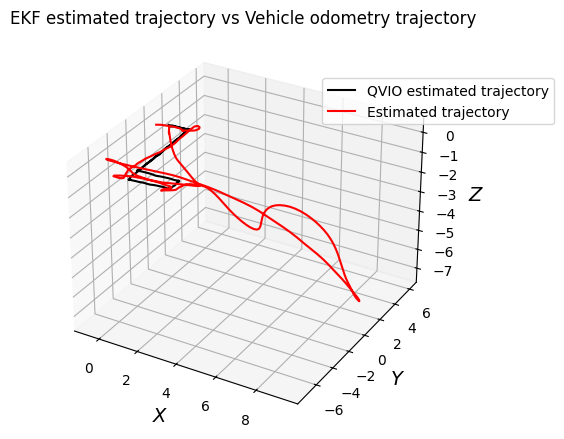

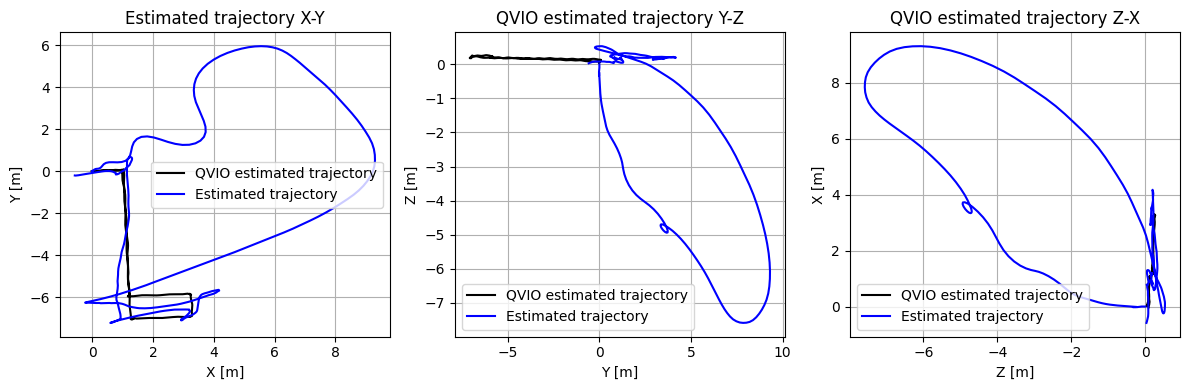

In [21]:
x = np.array([
    [0.],
    [0.],
    [0.],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.eye(10)[:3, :]
q = np.array([0.01, 0.01, 0.01, 0.0035, 0.0035, 0.0035])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo = np.array([0.1, 0.1, 0.1])

ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1
)

ekf_error = ekf.run(
    data=loader, 
    debug_mode=debug_mode,
    measurement_type=measurement_type
)

visualize_trajectory(loader=loader, mu_x=ekf.mu_x, mu_y=ekf.mu_y, mu_z=ekf.mu_z)

## UKF

[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████| 447/447 [00:00<00:00, 1204.04it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1.124 m
Root Mean Squared Error: 1.35 m
Maximum Error: 3.435 m
---------------------------------------------------



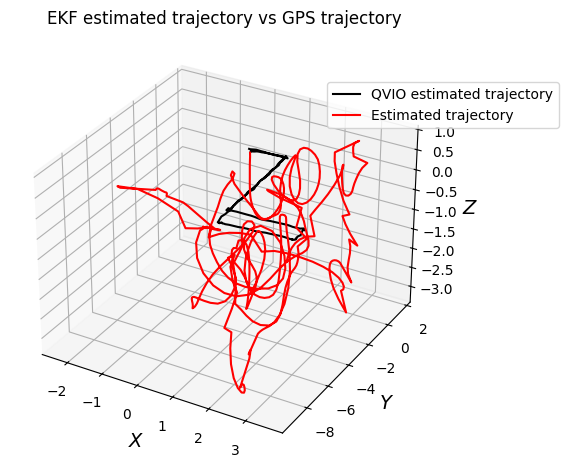

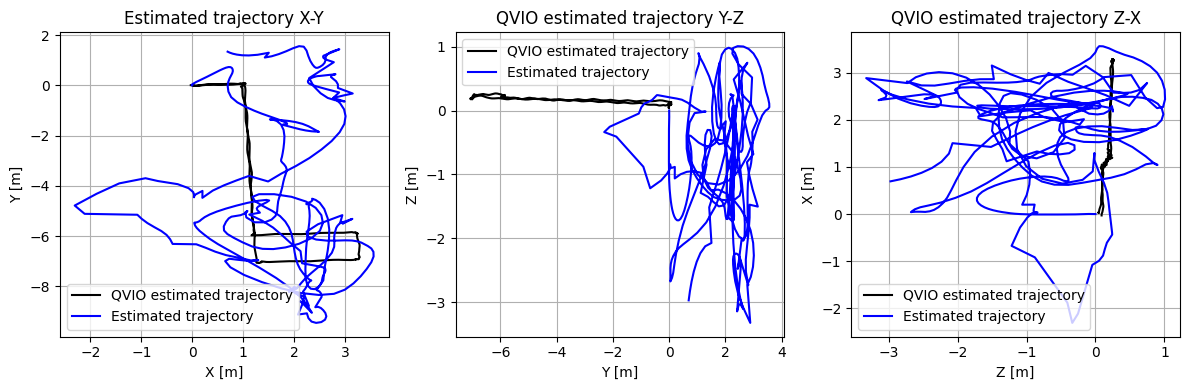

In [10]:
x = np.array([
    [0.],
    [0.],
    [0.],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.eye(10)[:3, :]
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo = np.array([0.1, 0.1, 0.1])

alpha_setup = 1.
beta_setup = 2.
kappa_setup = 0.

ukf = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(),
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    alpha=alpha_setup, 
    beta=beta_setup, 
    kappa=kappa_setup,
    setup=SetupEnum.SETUP_1
)

error_ukf1_0 = ukf.run(
    data=loader,
    debug_mode=debug_mode,
    measurement_type=measurement_type
)

visualize_trajectory(loader=loader, mu_x=ukf.mu_x, mu_y=ukf.mu_y, mu_z=ukf.mu_z)

## PF

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████| 447/447 [00:18<00:00, 23.81it/s]


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 2771.514 m
Root Mean Squared Error: 4955.926 m
Maximum Error: 18589.207 m
--------------------------------------------------



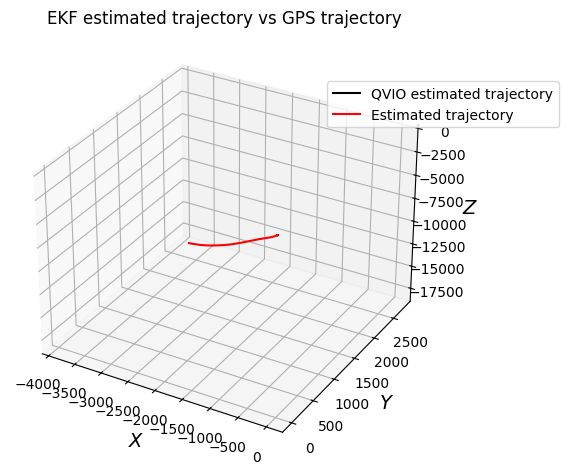

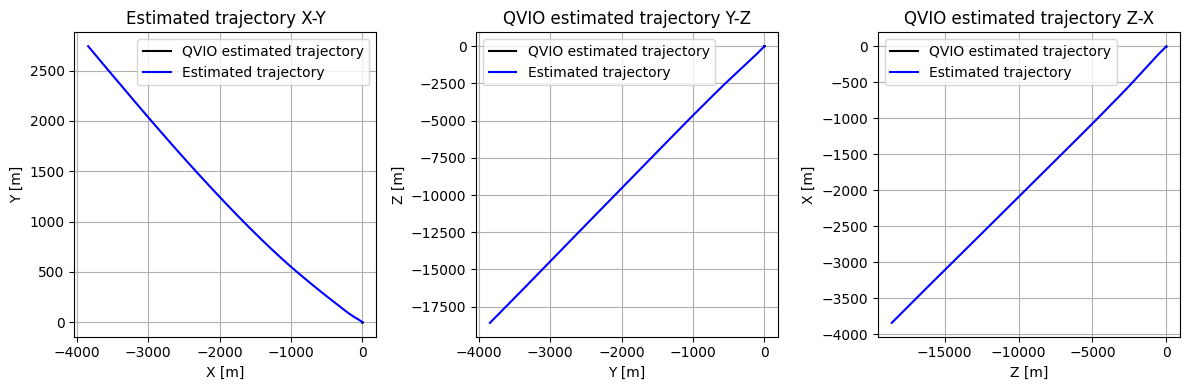

In [11]:
x = np.array([
    [0.],
    [0.],
    [0.],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.eye(10)[:3, :]
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo = np.array([0.1, 0.1, 0.1])

importance_resampling = True

pf = ParticleFilter(
    N=2048, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=ResamplingAlgorithms.STRATIFIED)
pf.create_gaussian_particles(mean=x.copy(), var=P.copy())

error_pf = pf.run(
    data=loader, 
    debug_mode=debug_mode,
    measurement_type=measurement_type, 
    importance_resampling=importance_resampling
)
visualize_trajectory(loader=loader, mu_x=pf.mu_x, mu_y=pf.mu_y, mu_z=pf.mu_z)

## EnKF

[EnKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████| 447/447 [00:05<00:00, 75.09it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.026 m
Root Mean Squared Error: 0.067 m
Maximum Error: 0.631 m
----------------------------------------------------



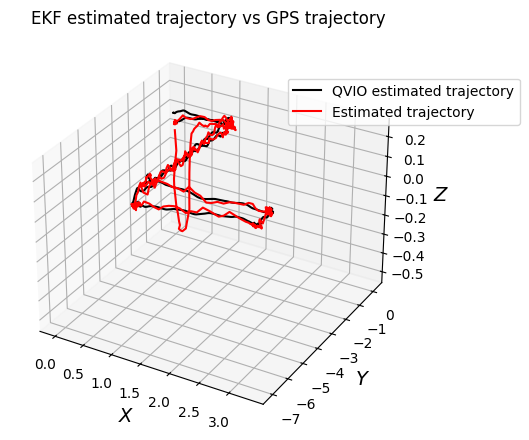

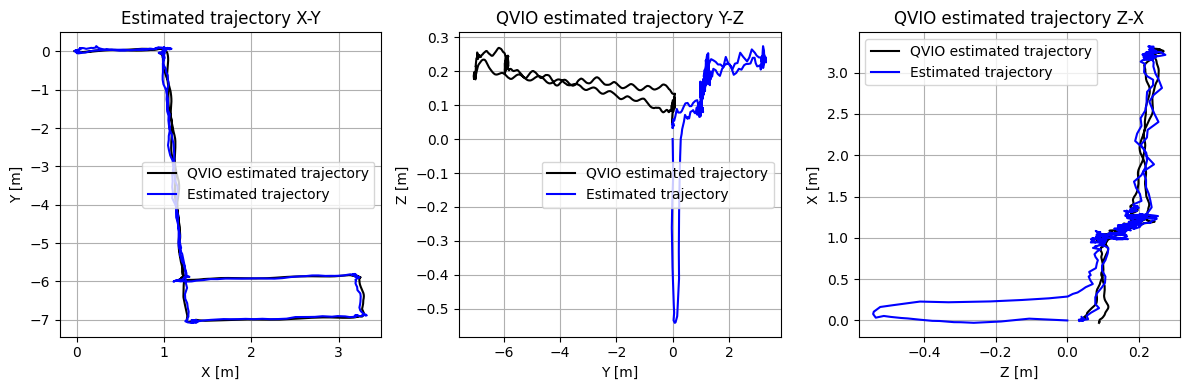

In [12]:
x = np.array([
    [0.],
    [0.],
    [0.],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.eye(10)[:3, :]
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo = np.array([0.1, 0.1, 0.1])

n_ensemble = 1024
enkf = EnsembleKalmanFilter(
    N=n_ensemble, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1
)
error_enkf = enkf.run(
    data=loader, 
    debug_mode=debug_mode, 
    measurement_type=measurement_type
)


visualize_trajectory(loader=loader, mu_x=enkf.mu_x, mu_y=enkf.mu_y, mu_z=enkf.mu_z)

## CKF

[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████| 447/447 [00:00<00:00, 1259.41it/s]



----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.339 m
Root Mean Squared Error: 0.961 m
Maximum Error: 5.458 m
---------------------------------------------------



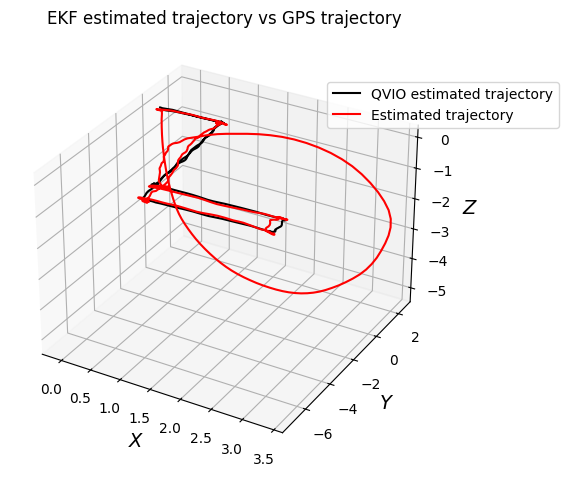

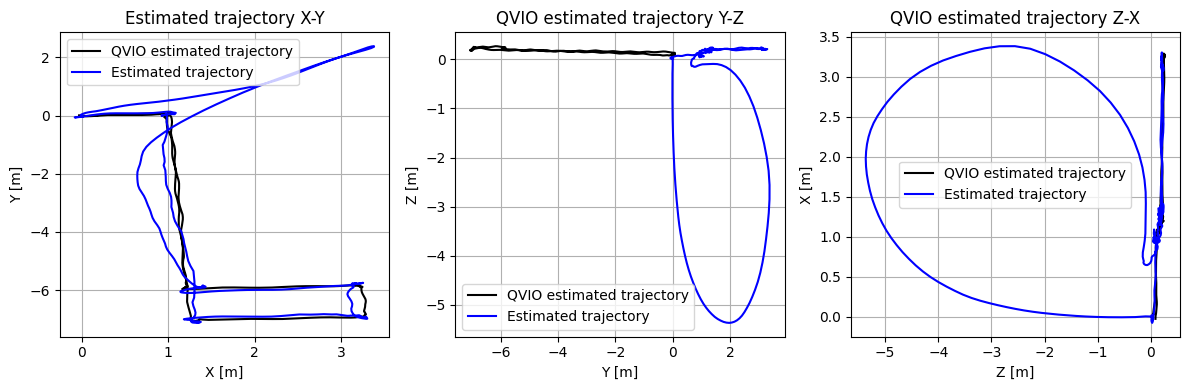

In [13]:
x = np.array([
    [0.],
    [0.],
    [0.],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.eye(x.shape[0])[:3, :]
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo = np.array([0.1, 0.1, 0.1])

ckf = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1,
)

error_ckf = ckf.run(
    data=loader, 
    debug_mode=debug_mode,
    measurement_type=measurement_type
)

visualize_trajectory(loader=loader, mu_x=ckf.mu_x, mu_y=ckf.mu_y, mu_z=ckf.mu_z)


# Velocity Motion Model (Setup3)

In [30]:
x = np.array([
    [0.],
    [0.],
    [0.],
    [0.],
    [0.],
])
P = np.eye(x.shape[0]) * 0.1
H = np.eye(5)[:3, :]
q = np.array([0.1, 0.1, 0.1, 0.0035, 0.0035])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo = np.array([0.1, 0.1, 0.1])

In [31]:
ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)

In [ ]:
t_last = df1.iloc[0]['timestamp']
df_reference = loader.get_sensors(timestamp=t_last)

ekf_mu_x = [x[0][0]]
ekf_mu_y = [x[1][0]]
ekf_mu_z = [x[2][0]]

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < loader.SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in loader.time_update:
            # Call Time update step
            u = np.array([
                data.INS_velocities_with_noise[t_idx, 0],
                data.IMU_angular_velocity_with_noise[t_idx, 0], #wx
                data.IMU_angular_velocity_with_noise[t_idx, 2] #wz
            ])
            ekf.predict_setup3(u=data.values, dt=dt, Q=ekf.Q)
            
        elif data_ref['device'] in loader.measurement_update:
            # Call Measurement update step
            if data_ref['device'] == 'voxl_vo':
                x_hat = ekf.x.copy()
                ekf_mu_x.append(x_hat[0, 0])
                ekf_mu_y.append(x_hat[1, 0])
                ekf_mu_z.append(x_hat[2, 0])
                
                z_vo = data[['T_imu_wrt_vio_x(m)', 'T_imu_wrt_vio_y(m)', 'T_imu_wrt_vio_z(m)']].values
                ekf.update(z=z_vo, R=ekf.R_vo)
                
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1


ekf_mu_x = np.array(ekf_mu_x)
ekf_mu_y = np.array(ekf_mu_y)
ekf_mu_z = np.array(ekf_mu_z)